# 09 - Los Peligros de la Extrapolacion

Un modelo de regresion **solo es valido dentro del rango de datos con los que fue entrenado**.

Usar el modelo para predecir fuera de ese rango se llama **extrapolacion**, y puede dar resultados absurdos.

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
print(
    f"Rango de square_meters: {df['square_meters'].min()} - {df['square_meters'].max()}"
)
print(f"Rango de price: {df['price'].min()} - {df['price'].max()}")
df.head()

Rango de square_meters: 51 - 200
Rango de price: 90600 - 442200


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
0,1,51,5,152700,2,1,2,4.7,0,5
1,2,52,44,132300,2,1,10,4.3,1,3
2,3,56,36,183200,2,1,1,6.6,1,6
3,4,57,6,170100,3,2,8,14.0,1,5
4,5,58,21,109500,2,1,1,18.0,1,5


## 1. El problema: predecir fuera del rango

Entrenemos un modelo simple y veamos que pasa cuando le pedimos predicciones **dentro** y **fuera** del rango de los datos.

In [5]:
# Modelo simple: precio vs metros cuadrados
X = df[["square_meters"]].to_numpy()
y = df["price"].to_numpy()

model = LinearRegression().fit(X, y)
print(
    f"Ecuacion: price = {model.intercept_:.2f} + {model.coef_[0]:.2f} * square_meters"
)
print(f"\nRango de entrenamiento: {X.min():.0f} - {X.max():.0f} m²")

# Predicciones dentro del rango (interpolacion - OK)
print("\n--- Interpolacion (dentro del rango) ---")
for sqm in [60, 80, 100]:
    pred = model.predict(np.array([[sqm]]))[0]
    print(f"  {sqm} m² -> ${pred:,.0f}")

# Predicciones fuera del rango (extrapolacion - PELIGRO)
print("\n--- Extrapolacion (fuera del rango) ---")
for sqm in [200, 500, 1000, 0]:
    pred = model.predict(np.array([[sqm]]))[0]
    print(
        f"  {sqm} m² -> ${pred:,.0f}  {'<-- ABSURDO' if pred < 0 or pred > 1_000_000 else ''}"
    )

Ecuacion: price = 44934.72 + 1582.17 * square_meters

Rango de entrenamiento: 51 - 200 m²

--- Interpolacion (dentro del rango) ---
  60 m² -> $139,865
  80 m² -> $171,508
  100 m² -> $203,152

--- Extrapolacion (fuera del rango) ---
  200 m² -> $361,368  
  500 m² -> $836,019  
  1000 m² -> $1,627,104  <-- ABSURDO
  0 m² -> $44,935  


## 2. Visualizando la extrapolacion

La linea de regresion es razonable **dentro** de los datos, pero se extiende infinitamente en ambas direcciones.

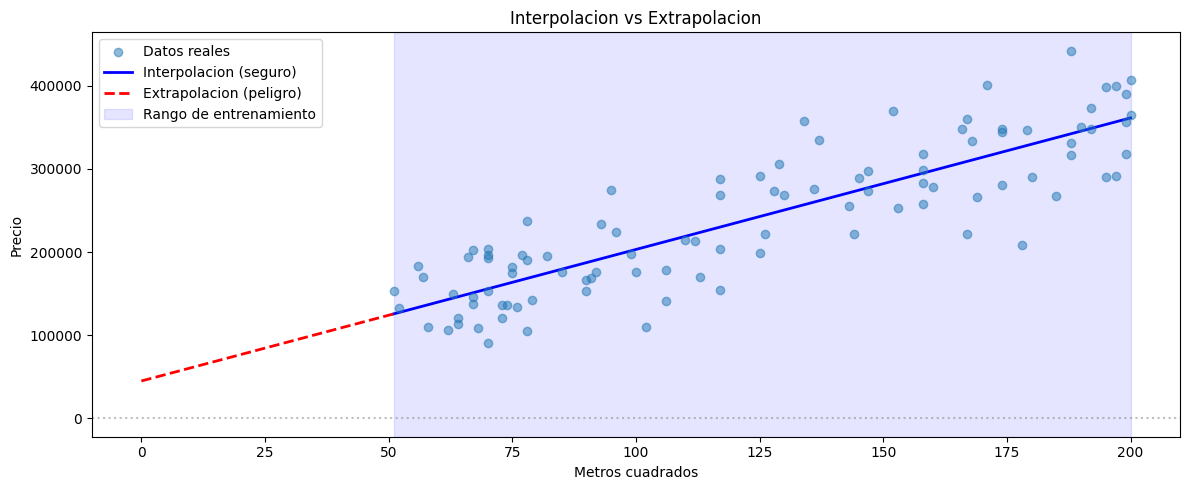

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

# Datos reales
ax.scatter(df["square_meters"], df["price"], alpha=0.5, label="Datos reales", zorder=3)

# Linea de regresion - rango seguro (interpolacion)
x_safe = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax.plot(
    x_safe, model.predict(x_safe), "b-", linewidth=2, label="Interpolacion (seguro)"
)

# Linea de regresion - extrapolacion izquierda
x_left = np.linspace(0, X.min(), 50).reshape(-1, 1)
ax.plot(
    x_left, model.predict(x_left), "r--", linewidth=2, label="Extrapolacion (peligro)"
)

# Linea de regresion - extrapolacion derecha
x_right = np.linspace(X.max(), 200, 50).reshape(-1, 1)
ax.plot(x_right, model.predict(x_right), "r--", linewidth=2)

# Zona segura
ax.axvspan(X.min(), X.max(), alpha=0.1, color="blue", label="Rango de entrenamiento")

ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Precio")
ax.set_title("Interpolacion vs Extrapolacion")
ax.legend()
plt.tight_layout()
plt.show()

## 3. El ejemplo del libro: prediccion absurda

El libro muestra un caso extremo: usar un modelo de casas para predecir el precio de un **terreno vacio** (sin construccion). Todas las variables de la construccion serian 0.

In [8]:
# Modelo con multiples variables
predictors = ["square_meters", "bedrooms", "bathrooms", "build_quality"]
X_multi = df[predictors].to_numpy()
y_multi = df["price"].to_numpy()

model_multi = LinearRegression().fit(X_multi, y_multi)

print("Ecuacion del modelo:")
print(f"  price = {model_multi.intercept_:.2f}")
for name, coef in zip(predictors, model_multi.coef_):
    print(f"         + {coef:.2f} * {name}")

print("\n--- Predicciones normales (dentro del rango) ---")
casa_normal = np.array([[80, 3, 2, 5]])
print(
    f"  Casa de 80m², 3 hab, 2 banos, calidad 5 -> ${model_multi.predict(casa_normal)[0]:,.0f}"
)

print("\n--- Prediccion absurda (terreno vacio) ---")
terreno_vacio = np.array([[0, 0, 0, 0]])
pred_absurda = model_multi.predict(terreno_vacio)[0]
print(f"  Terreno vacio (todo = 0) -> ${pred_absurda:,.0f}")
print(f"  El modelo predice un precio NEGATIVO porque nunca vio terrenos vacios")

Ecuacion del modelo:
  price = 5546.42
         + 1074.35 * square_meters
         + 10099.91 * bedrooms
         + 10873.54 * bathrooms
         + 7308.98 * build_quality

--- Predicciones normales (dentro del rango) ---
  Casa de 80m², 3 hab, 2 banos, calidad 5 -> $180,086

--- Prediccion absurda (terreno vacio) ---
  Terreno vacio (todo = 0) -> $5,546
  El modelo predice un precio NEGATIVO porque nunca vio terrenos vacios


## 4. Por que ocurre esto?

La regresion lineal asume que la relacion es una **linea recta infinita**. Pero en la realidad:

- Un terreno de 0 m² no puede tener precio negativo
- Un departamento de 1000 m² no sigue la misma tendencia que uno de 80 m²
- La relacion puede ser curva, tener limites, o cambiar de comportamiento

El modelo **no sabe nada de esto** porque solo aprendio de los datos que le dimos.

In [9]:
# Veamos los rangos reales de cada variable
print("Rangos de los datos de entrenamiento:")
print("(El modelo solo es confiable dentro de estos rangos)\n")
for col in predictors:
    print(f"  {col:25s}: {df[col].min():8.1f} - {df[col].max():.1f}")

print(f"\n  {'price':25s}: {df['price'].min():8.1f} - {df['price'].max():.1f}")

Rangos de los datos de entrenamiento:
(El modelo solo es confiable dentro de estos rangos)

  square_meters            :     51.0 - 200.0
  bedrooms                 :      1.0 - 6.0
  bathrooms                :      1.0 - 4.0
  build_quality            :      1.0 - 9.0

  price                    :  90600.0 - 442200.0


## 5. Detectando extrapolacion en la practica

Antes de usar predicciones, verifica si los valores de entrada estan dentro del rango de entrenamiento.

In [10]:
def check_extrapolation(new_data: dict, training_df: pd.DataFrame) -> None:
    """Verifica si los valores estan fuera del rango de entrenamiento."""
    warnings = []
    for col, value in new_data.items():
        col_min = training_df[col].min()
        col_max = training_df[col].max()
        if value < col_min or value > col_max:
            warnings.append(f"  {col} = {value} (rango: {col_min} - {col_max})")

    if warnings:
        print("ADVERTENCIA - Extrapolacion detectada en:")
        for w in warnings:
            print(w)
    else:
        print("OK - Todos los valores dentro del rango de entrenamiento")


# Caso seguro
print("Caso 1: Casa tipica")
check_extrapolation(
    {"square_meters": 80, "bedrooms": 3, "bathrooms": 2, "build_quality": 5}, df
)

# Caso peligroso
print("\nCaso 2: Mansion enorme")
check_extrapolation(
    {"square_meters": 500, "bedrooms": 10, "bathrooms": 8, "build_quality": 10}, df
)

# Caso absurdo
print("\nCaso 3: Terreno vacio")
check_extrapolation(
    {"square_meters": 0, "bedrooms": 0, "bathrooms": 0, "build_quality": 0}, df
)

Caso 1: Casa tipica
OK - Todos los valores dentro del rango de entrenamiento

Caso 2: Mansion enorme
ADVERTENCIA - Extrapolacion detectada en:
  square_meters = 500 (rango: 51 - 200)
  bedrooms = 10 (rango: 1 - 6)
  bathrooms = 8 (rango: 1 - 4)
  build_quality = 10 (rango: 1 - 9)

Caso 3: Terreno vacio
ADVERTENCIA - Extrapolacion detectada en:
  square_meters = 0 (rango: 51 - 200)
  bedrooms = 0 (rango: 1 - 6)
  bathrooms = 0 (rango: 1 - 4)
  build_quality = 0 (rango: 1 - 9)


## 6. Resumen

| Concepto | Descripcion |
|----------|-------------|
| **Interpolacion** | Predecir dentro del rango de los datos. Confiable |
| **Extrapolacion** | Predecir fuera del rango de los datos. Peligroso |
| **Por que falla** | La regresion asume una relacion lineal infinita, pero la realidad tiene limites y curvas |
| **Como prevenirlo** | Verificar que los valores de entrada esten dentro del rango de entrenamiento |
| **Regla practica** | Si el modelo no vio datos similares durante el entrenamiento, no confies en la prediccion |